## Setup

In [37]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn - preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Sklearn - models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Sklearn - evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

# Model saving
import joblib

# Settings
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print("Libraries imported successfully!")

Libraries imported successfully!


## Section 1: Load Processed Data

In [38]:
# Load cleaned data
df = pd.read_csv('../data/processed/cleaned_data.csv')

print(f"Data shape: {df.shape}")
df.head()

Data shape: (499568, 10)


,Severity,Start_Lat,Start_Lng,Distance(mi),DangerousScore,n_road_features,has_traffic_control,Hour,DayOfWeek,SignificantWordCount
0,2,35.834797,-78.638512,0.000,0.0,0,0,13,1,2
1,2,36.088970,-96.011734,0.000,3.0,0,0,6,2,1
2,2,33.537049,-86.794445,0.152,1.0,1,0,14,6,2
3,2,34.071722,-117.612886,0.869,1.0,0,0,19,4,3
4,2,40.324235,-76.790464,0.166,0.0,0,0,12,4,2


In [39]:
# Define your original target variable
ORIGINAL_TARGET = 'Severity'  # <-- UPDATE THIS

print(f"Original Target: {ORIGINAL_TARGET}")
print(f"\nTarget statistics:")
print(df[ORIGINAL_TARGET].describe())

Original Target: Severity

Target statistics:
count    499568.000000
mean          2.212504
std           0.487601
min           1.000000
25%           2.000000
50%           2.000000
75%           2.000000
max           4.000000
Name: Severity, dtype: float64


## Section 2: Create Binned Target

In [40]:
# View the distribution before binning
print("Target distribution:")
print(f"Min: {df[ORIGINAL_TARGET].min():.2f}")
print(f"25th percentile: {df[ORIGINAL_TARGET].quantile(0.25):.2f}")
print(f"Median: {df[ORIGINAL_TARGET].median():.2f}")
print(f"75th percentile: {df[ORIGINAL_TARGET].quantile(0.75):.2f}")
print(f"Max: {df[ORIGINAL_TARGET].max():.2f}")

Target distribution:
Min: 1.00
25th percentile: 2.00
Median: 2.00
75th percentile: 2.00
Max: 4.00


### 2.2 Check Class Balance

*Is your binned target reasonably balanced?*

In [41]:
# Check class balance
class_counts = df['Severity'].value_counts()
class_percentages = df['Severity'].value_counts(normalize=True) * 100

print("Class Distribution:")
for cat in class_counts.index:
    print(f"{cat}: {class_counts[cat]} ({class_percentages[cat]:.1f}%)")

# Check for severe imbalance
min_class_pct = class_percentages.min()
if min_class_pct < 10:
    print(f"\nWarning: Smallest class is only {min_class_pct:.1f}% of data.")
    print("Consider adjusting your binning strategy.")
else:
    print(f"\nClass balance looks reasonable!")

Class Distribution:
2: 397930 (79.7%)
3: 84051 (16.8%)
4: 13232 (2.6%)
1: 4355 (0.9%)

Consider adjusting your binning strategy.


## Section 3: Feature Consistency Check

**Important:** For consistency, you should use the same features for classification as you did for regression. This makes your app simpler (users enter the same inputs for both models) and allows for fair comparison.

If you decide to use different features, provide a strong justification below.

### Feature Selection Decision

In [43]:
df.columns.tolist()

['Severity',
 'Start_Lat',
 'Start_Lng',
 'Distance(mi)',
 'DangerousScore',
 'n_road_features',
 'has_traffic_control',
 'Hour',
 'DayOfWeek',
 'SignificantWordCount']

In [44]:
SELECTED_FEATURES = [
    'Start_Lat',
    'Start_Lng',
    'Distance(mi)',
    'DangerousScore',
    'n_road_features',
    'has_traffic_control',
    'Hour',
    'DayOfWeek',
    'SignificantWordCount'
 ]

## Section 4: Prepare Features and Target

In [45]:
# Create feature matrix using SELECTED features
X = df[SELECTED_FEATURES].copy()
y = df['Severity']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures used: {X.columns.tolist()}")
print(f"\nTarget classes: {y.unique().tolist()}")

Features shape: (499568, 9)
Target shape: (499568,)

Features used: ['Start_Lat', 'Start_Lng', 'Distance(mi)', 'DangerousScore', 'n_road_features', 'has_traffic_control', 'Hour', 'DayOfWeek', 'SignificantWordCount']

Target classes: [2, 4, 3, 1]


### 4.1 Label Encoding

Many sklearn models require numeric targets. Use LabelEncoder to convert category names to numbers.

In [46]:
# Encode your target labels to numbers using LabelEncoder
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df['Severity'])

In [47]:
# Verify encoding (run this to check)
print("Label encoding:")
for i, label in enumerate(label_encoder.classes_):
    print(f"{label} -> {i}")

Label encoding:
1 -> 0
2 -> 1
3 -> 2
4 -> 3


## Section 5: Train-Test Split

For classification, we use **stratified** splitting to ensure each class is proportionally represented in both train and test sets.

In [48]:
# Split your data with stratification

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [49]:
# Verify split and stratification
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

print(f"\nTraining class distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {label_encoder.classes_[u]}: {c} ({c/len(y_train)*100:.1f}%)")

Training set: 399654 samples
Test set: 99914 samples

Training class distribution:
  1: 3484 (0.9%)
  2: 318344 (79.7%)
  3: 67241 (16.8%)
  4: 10585 (2.6%)


In [50]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)

class_weights = dict(zip(classes, weights))

for k,v in class_weights.items():    
    print(f"{k}: {v:.2f}")

0: 28.68
1: 0.31
2: 1.49
3: 9.44


In [51]:
# Verify split and stratification
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

print(f"\nTraining class distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f" {c} ({c/len(y_train)*100:.1f}%)")

Training set: 399654 samples
Test set: 99914 samples

Training class distribution:
 3484 (0.9%)
 318344 (79.7%)
 67241 (16.8%)
 10585 (2.6%)


## Section 6: Feature Scaling

In [52]:
# Scale your features using StandardScaler

standard_scaler = StandardScaler()
X_train_scaled = standard_scaler.fit_transform(X_train)
X_test_scaled = standard_scaler.transform(X_test)

In [53]:
# Convert to DataFrame (helpful for later)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Features scaled successfully!")
print(f"Scaler fitted on {len(SELECTED_FEATURES)} features.")

Features scaled successfully!
Scaler fitted on 9 features.


## Section 7: Baseline Model

In [54]:
# This helper function evaluates any classifier - you'll use it throughout
def evaluate_classifier(model, X_train, X_test, y_train, y_test, model_name):
    """Train classifier and return evaluation metrics."""
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Calculate metrics
    results = {
        'Model': model_name,
        'Train Accuracy': accuracy_score(y_train, y_train_pred),
        'Test Accuracy': accuracy_score(y_test, y_test_pred),
        'Precision (weighted)': precision_score(y_test, y_test_pred, average='weighted'),
        'Recall (weighted)': recall_score(y_test, y_test_pred, average='weighted'),
        'F1 (weighted)': f1_score(y_test, y_test_pred, average='weighted')
    }
    
    return results, model, y_test_pred

## Section 9: Model Iteration

In [61]:
# Store all results
all_results = []


### Model 2: Decision Tree

In [63]:
# Create and evaluate a baseline Logistic Regression model

baseline_model = LogisticRegression(random_state=42, max_iter=1000)
baseline_results, baseline_trained, baseline_preds = evaluate_classifier(baseline_model, X_train_scaled, X_test_scaled, y_train, y_test, 'LogisticRegression')

trained_models = {
    'Logistic Regression (Baseline)': baseline_trained
}
all_results.append(baseline_results)

# Print results
print(f"Logistic Regression (Baseline) - Test Accuracy: {baseline_results['Test Accuracy']:.4f}, F1: {baseline_results['F1 (weighted)']:.4f}")

Logistic Regression (Baseline) - Test Accuracy: 0.7936, F1: 0.7089


In [64]:
# Create and evaluate a Decision Tree classifier

# YOUR CODE HERE:
dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_results, dt_trained, dt_preds = evaluate_classifier(dt_model, X_train_scaled, X_test_scaled, y_train, y_test, 'DecisionTree')

trained_models['DecisionTree'] = dt_trained
all_results.append(dt_results)

# Print results
print(f"Decision Tree - Test Accuracy: {dt_results['Test Accuracy']:.4f}, F1: {dt_results['F1 (weighted)']:.4f}")

Decision Tree - Test Accuracy: 0.8556, F1: 0.8408


### Model 3: Random Forest

In [65]:
# Create and evaluate a Random Forest classifier

rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42)
rf_results, rf_trained, rf_preds = evaluate_classifier(rf_model, X_train_scaled, X_test_scaled, y_train, y_test, 'RandomForest')

trained_models['RandomForest'] = rf_trained
all_results.append(rf_results)

# Print results
print(f"Random Forest - Test Accuracy: {rf_results['Test Accuracy']:.4f}, F1: {rf_results['F1 (weighted)']:.4f}")

Random Forest - Test Accuracy: 0.5895, F1: 0.6701


### Model 4: K-Nearest Neighbors

In [66]:
# Create and evaluate a KNN classifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_results, knn_trained, knn_preds = evaluate_classifier(knn_model, X_train_scaled, X_test_scaled, y_train, y_test, 'KNN')

trained_models['KNN'] = knn_trained
all_results.append(knn_results)

# Print results
print(f"KNN - Test Accuracy: {knn_results['Test Accuracy']:.4f}, F1: {knn_results['F1 (weighted)']:.4f}")

KNN - Test Accuracy: 0.8066, F1: 0.7843


### Model 5: Gradient Boosting

In [67]:
# Create and evaluate a Gradient Boosting classifier

gb_model = GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42)
gb_results, gb_trained, gb_preds = evaluate_classifier(gb_model, X_train_scaled, X_test_scaled, y_train, y_test, 'GradientBoosting')

trained_models['GradientBoosting'] = gb_trained
all_results.append(gb_results)

# Print results
print(f"Gradient Boosting - Test Accuracy: {gb_results['Test Accuracy']:.4f}, F1: {gb_results['F1 (weighted)']:.4f}")

Gradient Boosting - Test Accuracy: 0.8644, F1: 0.8496


### Add Your Own Model (Optional)

Try a different model or different hyperparameters!

In [ ]:
# YOUR ADDITIONAL MODEL HERE:
# Try SVC, different hyperparameters, or another classifier
svc_model = SVC(kernel='linear', C=1.0, random_state=42)
svc_results, svc_trained, svc_preds = evaluate_classifier(svc_model, X_train_scaled, X_test_scaled, y_train, y_test, 'SVC')

trained_models['SVC'] = svc_trained
all_results.append(svc_results)

# Print results
print(f"SVC - Test Accuracy: {svc_results['Test Accuracy']:.4f}, F1: {svc_results['F1 (weighted)']:.4f}")


In [68]:

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100, 
    max_depth=5, 
    #min_child_weight=5,
    gamma=1,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    n_jobs=-1,
    eval_metric='mlogloss',
    random_state=42,
    objective='multi:softprob',
    num_class=4,
    scale_pos_weight=class_weights  # per class tuning
)

xgb_results, xgb_trained, xgb_preds = evaluate_classifier(xgb_model, X_train_scaled, X_test_scaled, y_train, y_test, 'XGBoost')

trained_models['XGBoost'] = xgb_trained
all_results.append(xgb_results)

# Print results
print(f"XGBoost - Test Accuracy: {xgb_results['Test Accuracy']:.4f}, F1: {xgb_results['F1 (weighted)']:.4f}")



XGBoost - Test Accuracy: 0.8588, F1: 0.8424


In [70]:
from sklearn.ensemble import HistGradientBoostingClassifier

histgrad_model = HistGradientBoostingClassifier()
histgrad_results, histgrad_trained, histgrad_preds = evaluate_classifier(histgrad_model, X_train_scaled, X_test_scaled, y_train, y_test, 'HistGradientBoosting')
trained_models['HistGradientBoosting'] = histgrad_trained
all_results.append(histgrad_results)

# Print results
print(f"HistGradientBoosting - Test Accuracy: {histgrad_results['Test Accuracy']:.4f}, F1: {histgrad_results['F1 (weighted)']:.4f}")

HistGradientBoosting - Test Accuracy: 0.8641, F1: 0.8508


## Section 10: Model Comparison

In [71]:
# Create comparison DataFrame
results_df = pd.DataFrame(all_results)
results_df = results_df.round(4)
results_df = results_df.sort_values('Test Accuracy', ascending=False)

print("Model Comparison:")
results_df

Model Comparison:


,Model,Train Accuracy,Test Accuracy,Precision (weighted),Recall (weighted),F1 (weighted)
7,HistGradientBoosting,0.8689,0.8666,0.8546,0.8666,0.8538
5,GradientBoosting,0.8672,0.8644,0.8524,0.8644,0.8496
8,HistGradientBoosting,0.8666,0.8641,0.8515,0.8641,0.8508
6,XGBoost,0.8598,0.8588,0.8474,0.8588,0.8424
2,DecisionTree,0.8595,0.8556,0.8375,0.8556,0.8408
4,KNN,0.8553,0.8066,0.7766,0.8066,0.7843
0,LogisticRegression,0.7932,0.7936,0.6907,0.7936,0.7089
1,LogisticRegression,0.7932,0.7936,0.6907,0.7936,0.7089
3,RandomForest,0.5898,0.5895,0.8576,0.5895,0.6701


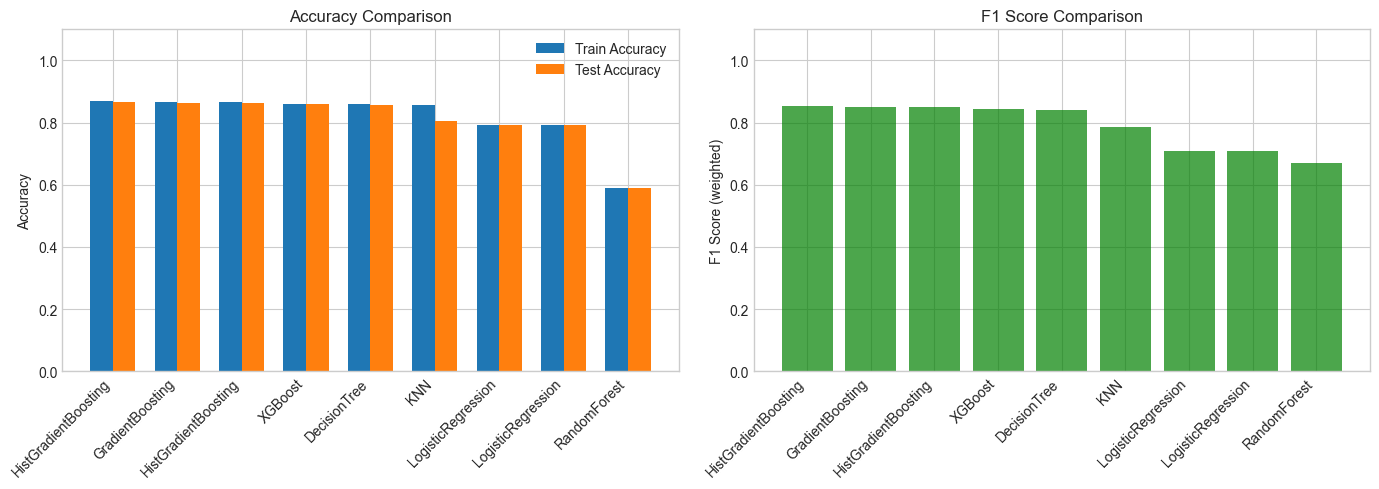

In [72]:
# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = results_df['Model']
x = np.arange(len(models))
width = 0.35

# Accuracy comparison
axes[0].bar(x - width/2, results_df['Train Accuracy'], width, label='Train Accuracy')
axes[0].bar(x + width/2, results_df['Test Accuracy'], width, label='Test Accuracy')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=45, ha='right')
axes[0].legend()
axes[0].set_ylim(0, 1.1)

# F1 Score comparison
axes[1].bar(x, results_df['F1 (weighted)'], color='green', alpha=0.7)
axes[1].set_ylabel('F1 Score (weighted)')
axes[1].set_title('F1 Score Comparison')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=45, ha='right')
axes[1].set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

## Section 11: Best Model Selection

In [73]:
# Identify best model (by test accuracy)
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]

print(f"Best Model: {best_model_name}")
print(f"Test Accuracy: {results_df.iloc[0]['Test Accuracy']:.4f}")
print(f"F1 Score: {results_df.iloc[0]['F1 (weighted)']:.4f}")

Best Model: HistGradientBoosting
Test Accuracy: 0.8666
F1 Score: 0.8538


### Best Model Justification

*Explain why you chose this model:*
We chose Gradient Boosting because it has the best test accuracy.

**Questions to consider:**
- Why this model over others?
- Is there significant overfitting?
- How does it compare to baseline?
- Which metrics did you prioritize and why?

**Your justification:**

This model shows the best F1 score, which indicates it has a good balance of precision and recall. 

In general all models show very slight overfitting based on the Train vs Test accuracy, which is a good sign.

Compared to the baseline model, Gradient Boosting significantly improves performance, indicating that it effectively captures the underlying patterns in the data.

While evaluating overfitting, we we follow train/test metrics; also very importantly we look at F1 score, which is a good metric to evaluate the balance between precision and recall.

## Section 12: Best Model Analysis

In [75]:
# Get predictions from best model
y_pred = best_model.predict(X_test_scaled)

# Detailed classification report
print("Classification Report:")
print("=" * 50)

print(classification_report(
    y_test,
    y_pred,
    labels=[0, 1, 2, 3],
    target_names=['1', '2', '3', '4']
))

Classification Report:
              precision    recall  f1-score   support

           1       0.48      0.27      0.35       871
           2       0.89      0.95      0.92     79586
           3       0.72      0.63      0.67     16810
           4       0.58      0.06      0.12      2647

    accuracy                           0.86     99914
   macro avg       0.67      0.48      0.51     99914
weighted avg       0.85      0.86      0.85     99914



### Understanding the Classification Report

The classification report shows per-class metrics:

- **Precision:** Of all predictions for this class, what % were correct?
  - High precision = Few false positives
  - Example: "When the model predicts 'High', it's correct 85% of the time"

- **Recall:** Of all actual instances of this class, what % did we find?
  - High recall = Few false negatives
  - Example: "We correctly identified 90% of all actual 'High' cases"

- **F1-Score:** Harmonic mean of precision and recall (balanced measure)
  - Good when you need both precision and recall

- **Support:** Number of actual occurrences of each class in the test set

<Figure size 800x600 with 0 Axes>

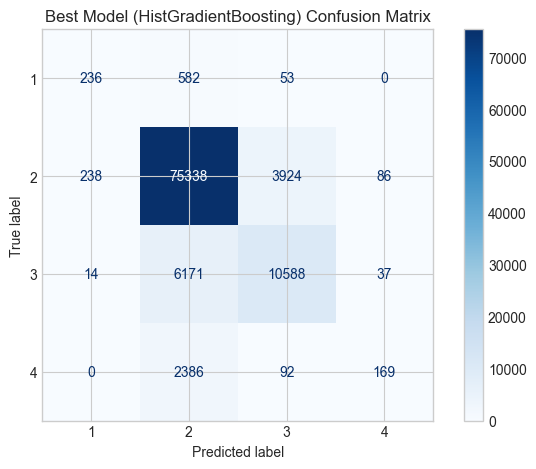

In [77]:
# Confusion matrix for best model
cm = confusion_matrix(y_test, histgrad_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)

plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues')
plt.title(f'Best Model ({best_model_name}) Confusion Matrix')
plt.tight_layout()
plt.show()

In [79]:
print("X columns:", len(X.columns))
print("importances:", len(gb_model.feature_importances_))

X columns: 9
importances: 9


In [80]:
# Feature importance (if available)
if hasattr(best_model, 'feature_importances_'):
    importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=True)
    
    plt.figure(figsize=(10, 6))
    plt.barh(importance['Feature'], importance['Importance'])
    plt.xlabel('Importance')
    plt.title('Feature Importance for Classification')
    plt.tight_layout()
    plt.show()
    
    print("\nTop 5 most important features:")
    for i, row in importance.tail(5).iloc[::-1].iterrows():
        print(f"  {row['Feature']}: {row['Importance']:.4f}")
        
elif hasattr(best_model, 'coef_'):
    # For multi-class, coef_ has shape (n_classes, n_features)
    coef = best_model.coef_
    if len(coef.shape) > 1:
        # Average absolute importance across classes
        importance_vals = np.abs(coef).mean(axis=0)
    else:
        importance_vals = np.abs(coef)
    
    importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': importance_vals
    }).sort_values('Importance', ascending=True)
    
    plt.figure(figsize=(10, 6))
    plt.barh(importance['Feature'], importance['Importance'])
    plt.xlabel('Average Absolute Coefficient')
    plt.title('Feature Importance for Classification')
    plt.tight_layout()
    plt.show()